# Mini LLM (Transformer) from Scratch
Run cells top to bottom.

In [ ]:
import torch 
import torch.nn as nn
import torch.nn.functional as F 
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.animation import FuncAnimation

%matplotlib widget

print ("torch working ")


RuntimeError: 'widget' is not a recognised GUI loop or backend name

In [17]:
text = "My name is vikalp and i am learning AI and LLMs"
chars = sorted(list(set(text)))
vocab_size = len(chars)
print ("vocab size : ", vocab_size)

stoi = { ch:i for i,ch in enumerate(chars) }
itos = { i:ch for i,ch in enumerate(chars) }

def encode(s):
    return [stoi[c] for c in s]

def decode(l):
    return ''.join([itos[i] for i in l])

print ("encoded text : ", encode(text))
print ("decoded text : ", decode(encode(text)))

data = torch.tensor(encode(text), dtype=torch.long)
print ("data : ", data)
print ("data shape : ", data.shape)

n = int(0.9*len(data))
train_data = data[:n]

print ("train data : ", train_data)
print("train data shape : ", train_data.shape)

vocab size :  19
encoded text :  [4, 18, 0, 13, 5, 12, 7, 0, 9, 16, 0, 17, 9, 10, 5, 11, 14, 0, 5, 13, 6, 0, 9, 0, 5, 12, 0, 11, 7, 5, 15, 13, 9, 13, 8, 0, 1, 2, 0, 5, 13, 6, 0, 3, 3, 4, 16]
decoded text :  My name is vikalp and i am learning AI and LLMs
data :  tensor([ 4, 18,  0, 13,  5, 12,  7,  0,  9, 16,  0, 17,  9, 10,  5, 11, 14,  0,
         5, 13,  6,  0,  9,  0,  5, 12,  0, 11,  7,  5, 15, 13,  9, 13,  8,  0,
         1,  2,  0,  5, 13,  6,  0,  3,  3,  4, 16])
data shape :  torch.Size([47])
train data :  tensor([ 4, 18,  0, 13,  5, 12,  7,  0,  9, 16,  0, 17,  9, 10,  5, 11, 14,  0,
         5, 13,  6,  0,  9,  0,  5, 12,  0, 11,  7,  5, 15, 13,  9, 13,  8,  0,
         1,  2,  0,  5, 13,  6])
train data shape :  torch.Size([42])


In [18]:
block_size = 16
batch_size = 4
n_enbd = 32
n_head = 4
n_layer = 2


In [19]:
def get_batch(split):
    data = train_data if split == 'train' else val_data
    ix = torch.randint(len(data) - block_size, (batch_size,))
    x = torch.stack([data[i:i+block_size] for i in ix])
    y = torch.stack([data[i+1:i+block_size+1] for i in ix])
    return x, y

xb, yb = get_batch('train')
print ("xb shape : ", xb.shape)
print ("yb shape : ", yb.shape)

xb shape :  torch.Size([4, 16])
yb shape :  torch.Size([4, 16])


In [21]:
class Head(nn.Module):
    def __init__(self, head_size):
        super().__init__()
        self.key = nn.Linear(n_enbd, head_size, bias=False)
        self.query = nn.Linear(n_enbd, head_size, bias=False)
        self.value = nn.Linear(n_enbd, head_size, bias=False)
        self.register_buffer('tril', torch.tril(torch.ones(block_size, block_size)))
    
    def forward(self, x):
        B,T,C = x.shape
        k = self.key(x)   # (B,T,head_size)
        q = self.query(x) # (B,T,head_size)
       

        wei = q @ k.transpose(-2,-1) * C**-0.5  # (B,T,head_size) @ (B, head_size,T) -> (B,T,T)
        wei = wei.masked_fill(self.tril[:T,:T] == 0, float('-inf'))  # (B,T,T)
        wei = F.softmax(wei, dim=-1)  # (B,T,T)

        v = self.value(x) # (B,T,head_size)
        out = wei @ v # (B,T,T) @ (B,T,head_size) -> (B,T,head_size)
        return out
        
       

In [22]:
class MultiHeadAttention(nn.Module):
    def __init__(self, num_heads, head_size):
        super().__init__()
        self.heads = nn.ModuleList([Head(head_size) for _ in range(num_heads)])
        self.proj = nn.Linear(n_enbd, n_enbd)
    
    def forward(self, x):
        out = torch.cat([h(x) for h in self.heads], dim=-1)
        out = self.proj(out)
        return out

In [23]:
class FeedForward(nn.Module):
    def __init__(self, n_enbd):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_enbd, 4*n_enbd),
            nn.ReLU(),
            nn.Linear(4*n_enbd, n_enbd)
        )
    
    def forward(self, x):
        return self.net(x)

In [24]:
class Block(nn.Module):
    def __init__(self, n_enbd, n_head):
        super().__init__()
        head_size = n_enbd // n_head
        self.sa = MultiHeadAttention(n_head, head_size)
        self.ffwd = FeedForward(n_enbd)
        self.ln1 = nn.LayerNorm(n_enbd)
        self.ln2 = nn.LayerNorm(n_enbd)
    
    def forward(self, x):
        x = x + self.sa(self.ln1(x))
        x = x + self.ffwd(self.ln2(x))
        return x

In [25]:
class GPTLanguageModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.token_embedding_table = nn.Embedding(vocab_size, n_enbd)
        self.position_embedding_table = nn.Embedding(block_size, n_enbd)
        self.blocks = nn.Sequential(*[Block(n_enbd, n_head) for _ in range(n_layer)])
        self.ln_f = nn.LayerNorm(n_enbd)
        self.head = nn.Linear(n_enbd, vocab_size)
    
    def forward(self, idx, targets=None):
        B,T = idx.shape
        token_emb = self.token_embedding_table(idx) # (B,T,n_enbd)
        pos_emb = self.position_embedding_table(torch.arange(T)) # (T,n_enbd)
        x = token_emb + pos_emb # (B,T,n_enbd)
        x = self.blocks(x) # (B,T,n_enbd)
        x = self.ln_f(x) # (B,T,n_enbd)
        logits = self.head(x) # (B,T,vocab_size)

        if targets is None:
            loss = None
        else:
            B,T,C = logits.shape
            logits = logits.view(B*T, C)
            targets = targets.view(B*T)
            loss = F.cross_entropy(logits, targets)

        return logits, loss
    
    def generate(self, idx, max_new_tokens):
        for _ in range(max_new_tokens):
            idx_cond = idx[:,-block_size:]
            logits, _ = self(idx_cond)
            logits = logits[:,-1,:]
            probs = F.softmax(logits, dim=-1)
            next_id = torch.multinomial(probs, num_samples=1)
            idx = torch.cat((idx, next_id), dim=1)
        return idx

In [26]:
model = GPTLanguageModel()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)

losses = []
for iter in range(2000):
    xb, yb = get_batch('train')
    logits, loss = model(xb, yb)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.item())
    if iter % 200 == 0:
        print (f"iteration {iter} : loss {loss.item()}")

iteration 0 : loss 3.1970934867858887
iteration 200 : loss 0.4109402000904083
iteration 400 : loss 0.09804235398769379
iteration 600 : loss 0.03980501741170883
iteration 800 : loss 0.11825574189424515
iteration 1000 : loss 0.05680199712514877
iteration 1200 : loss 0.046257004141807556
iteration 1400 : loss 0.050858888775110245
iteration 1600 : loss 0.0677659884095192
iteration 1800 : loss 0.11498764157295227


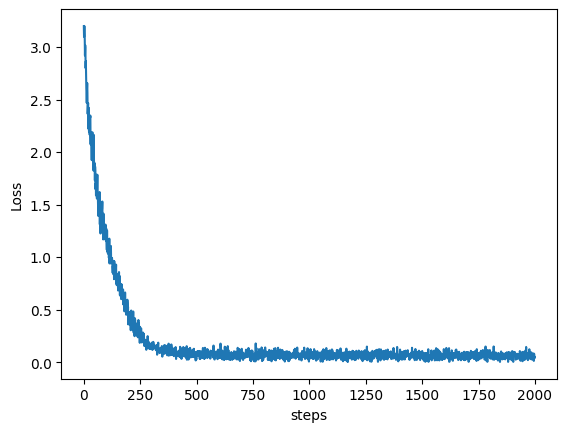

In [27]:
plt.Figure()
plt.plot(losses)
plt.xlabel("Trainning loss Curve")
plt.xlabel("steps")
plt.ylabel("Loss")
plt.show()

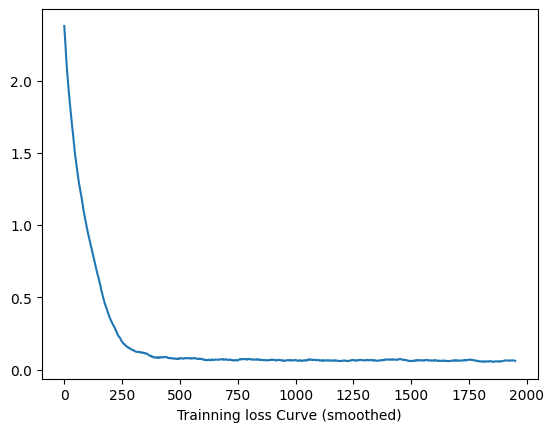

In [28]:
smoothed = np.convolve(losses, np.ones(50)/50, mode='valid')
plt.plot(smoothed)
plt.xlabel("Trainning loss Curve (smoothed)")
plt.show()

In [15]:
context = torch.zeros((1,1), dtype=torch.long)
generated_idx = model.generate(context, max_new_tokens=100)
print (decode(generated_idx[0].tolist()))

 i am learning AI and i am learning AI and i am learning AI and i am learning AI and i am learning AI


NameError: name 'HTML' is not defined

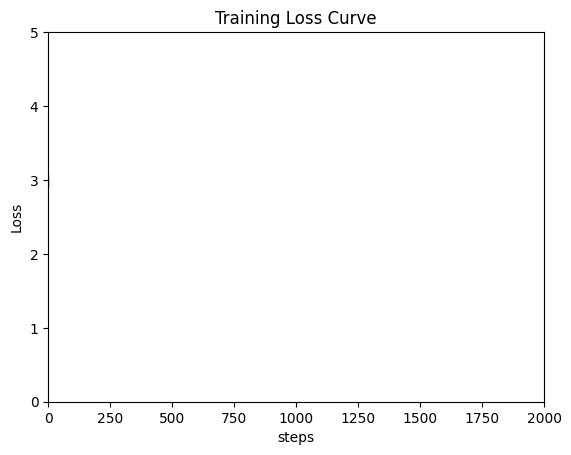

In [ ]:
model = GPTLanguageModel()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)

losses = []
figure, ax = plt.subplots()
line, = ax.plot([], [])
ax.set_xlim(0, 2000)
ax.set_ylim(0, 5)
ax.set_title("Training Loss Curve")
ax.set_xlabel("steps")
ax.set_ylabel("Loss")   

def update(steps) :
    xb, yb = get_batch('train')
    logits, loss = model(xb, yb)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.item())
    
     # Smooth curve
    if len(losses) > 20:
        smoothed = np.convolve(losses, np.ones(20)/20, mode='valid')
        line.set_data(range(len(smoothed)), smoothed)
    else:
        line.set_data(range(len(losses)), losses)

    return line,

ani = FuncAnimation(figure, update, frames=range(2000), blit=True, repeat=False)
plt.show()